In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
#read csv files **Make sure to change the file paths**

abm = pd.read_csv("abm.csv")
card = pd.read_csv("card.csv")
cheque = pd.read_csv("cheque.csv")
eft = pd.read_csv("eft.csv")
emt = pd.read_csv("emt.csv")
kyc_individual = pd.read_csv("kyc_individual.csv")
kyc_industry_codes = pd.read_csv("kyc_industry_codes.csv")
kyc_occupation_codes = pd.read_csv("kyc_occupation_codes.csv")
kyc_smallbusiness = pd.read_csv("kyc_smallbusiness.csv")
labels = pd.read_csv("labels.csv")
westernunion = pd.read_csv("westernunion.csv")
wire = pd.read_csv("wire.csv")
merchant_codes = pd.read_csv("mcc_codes.csv")

In [3]:
#concat the card,cheque, eft, emt, abm, westernunion, wire dataset
eft['type'] = 'eft'
emt['type'] = 'emt'
abm['type'] = 'abm'
card['type'] = 'card'
cheque['type'] = 'cheque'
westernunion['type'] = 'westernunion'
wire['type'] = 'wire'
transactions = pd.concat([card, cheque, eft, emt, abm, westernunion, wire], ignore_index=True)
#merge transactions with labels
data = pd.merge(transactions, labels, on='customer_id', how='left')
transactions

,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,merchant_category,ecommerce_ind,country,province,city,type,cash_indicator
0,CARD24110131109543,SYNID0102450742,13.35,D,2024-11-01 00:00:06,5812,1.0,CA,ON,NaN,card,NaN
1,CARD24110136178868,SYNID0105586872,6.05,D,2024-11-01 00:00:17,5968,1.0,NaN,NaN,other,card,NaN
2,CARD24110173783589,SYNID0107901560,81.40,C,2024-11-01 00:00:37,4816,0.0,CA,BC,NaN,card,NaN
3,CARD24110142566805,SYNID0107237475,3.20,D,2024-11-01 00:00:41,5814,0.0,CA,ON,MISSISSAUGA,card,NaN
4,CARD24110150346602,SYNID0109982946,356.03,D,2024-11-01 00:00:51,0,0.0,CA,AB,CALGARY,card,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5903328,2501312027222151,SYNID0200494373,664383.06,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903329,2501314427775083,SYNID0107588495,6720.80,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903330,2501313191709047,SYNID0108770535,20251.28,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903331,2501318829419846,SYNID0100253336,17410.89,D,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN


In [4]:
# organize the transaction datetime and adjust the amount for debit and credit card transactions
transactions['transaction_datetime'] = pd.to_datetime(transactions['transaction_datetime'], format='mixed')
transactions.loc[transactions["debit_credit"] == "D","amount_cad"] *= -1
transactions['date'] = transactions['transaction_datetime'].dt.date
transactions = transactions.drop(columns='debit_credit')

In [5]:
# calculate the account age for each customer

# fill missing onboard_date with the date of first transaction
transactions = transactions.sort_values(['customer_id','date'])
first_trans_date = transactions.groupby('customer_id')['date'].min()

kyc_individual['onboard_date'] = pd.to_datetime(kyc_individual['onboard_date']).fillna(
    kyc_individual['customer_id'].map(first_trans_date)
)
kyc_individual['account_age'] = (pd.to_datetime('2025-01-31') - kyc_individual['onboard_date']).dt.days

kyc_smallbusiness['onboard_date'] = pd.to_datetime(kyc_smallbusiness['onboard_date']).fillna(
    kyc_smallbusiness['customer_id'].map(first_trans_date)
)
kyc_smallbusiness['account_age'] = (pd.to_datetime('2025-01-31') - kyc_smallbusiness['onboard_date']).dt.days

### Churn ratio in 7 Days

churn = outbound_7d/inbound_7d

In [6]:
# reconstruct a relative balance for each account

v_trans = transactions.copy()
v_trans['date'] = pd.to_datetime(v_trans['date'])

# calculate the net flow per account
v_trans['net_flow'] = v_trans.groupby('customer_id')['amount_cad'].cumsum()

In [7]:
# Calculate 7-Day Outbound Volume per Account

v_trans = v_trans.set_index('date')
outbound_7d = v_trans.groupby('customer_id')['amount_cad'].transform(
    lambda x: x.clip(upper=0).abs().rolling('7D').sum()
)

In [8]:
# Calculate 7-Day Inbound Volume per Account

inbound_7d = v_trans.groupby('customer_id')['amount_cad'].transform(
    lambda x: x.clip(lower=0).abs().rolling('7D').sum()
)

In [9]:
# Calculate churn ratio

v_trans['churn_ratio'] = outbound_7d / inbound_7d.replace(0,0.01)
v_trans.head(5)

,transaction_id,customer_id,amount_cad,transaction_datetime,merchant_category,ecommerce_ind,country,province,city,type,cash_indicator,net_flow,churn_ratio
date,,,,,,,,,,,,,
2024-11-03,EFT24110308130101,SYNID0100000167,42.05,2024-11-03 08:17:47,NaN,NaN,NaN,NaN,NaN,eft,NaN,42.05,0.000000
2024-11-08,EFT24110811242592,SYNID0100000167,-151.36,2024-11-08 09:42:04,NaN,NaN,NaN,NaN,NaN,eft,NaN,-109.31,3.599524
2024-11-14,EFT24111425421579,SYNID0100000167,984.14,2024-11-14 09:40:47,NaN,NaN,NaN,NaN,NaN,eft,NaN,874.83,0.153799
2024-11-15,EFT24111597610441,SYNID0100000167,-97.07,2024-11-15 09:41:53,NaN,NaN,NaN,NaN,NaN,eft,NaN,777.76,0.098634
2024-12-01,EFT24120157518765,SYNID0100000167,-253.16,2024-12-01 09:47:23,NaN,NaN,NaN,NaN,NaN,eft,NaN,524.60,25316.000000


In [10]:
# Calculate local Z-score of Churn Ratio for each account

kyc_age = pd.concat([kyc_individual[['customer_id','account_age']],kyc_smallbusiness[['customer_id','account_age']]],axis=0)
kyc_age = kyc_age.set_index('customer_id')['account_age']

# Calculate sum and sum of squared per account
stats = v_trans.groupby('customer_id')['churn_ratio'].agg(['sum', lambda x: (x**2).sum()]).reset_index()
stats.columns = ['customer_id', 'churn_sum', 'churn_sum_sq']

# User account age as denominator
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
stats['onboard_days'] = stats['customer_id'].map(kyc_age).clip(upper=window, lower=1)

# Calculate mean and std
stats['churn_mean'] = stats['churn_sum'] / stats['onboard_days']
stats['churn_std'] = np.sqrt((stats['churn_sum_sq'] / stats['onboard_days']) - (stats['churn_mean']**2)).fillna(0)

# Calculate local Z-score
v_trans = v_trans.merge(stats[['customer_id', 'churn_mean', 'churn_std']], on='customer_id')
v_trans['churn_z_score'] = (v_trans['churn_ratio'] - v_trans['churn_mean']) / v_trans['churn_std'].replace(0,0.01)

c:\Users\annxy\python\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [11]:
# construct flags for each transaction

v_trans['is_anomaly'] = (v_trans['churn_z_score'] > 3).astype(int)
v_trans['is_symmetric'] = (v_trans['churn_ratio'].between(0.9, 1.1)).astype(int)
v_trans.head(5)

,transaction_id,customer_id,amount_cad,transaction_datetime,merchant_category,ecommerce_ind,country,province,city,type,cash_indicator,net_flow,churn_ratio,churn_mean,churn_std,churn_z_score,is_anomaly,is_symmetric
0,EFT24110308130101,SYNID0100000167,42.05,2024-11-03 08:17:47,NaN,NaN,NaN,NaN,NaN,eft,NaN,42.05,0.000000,1441.431975,8806.815962,-0.163672,0,0
1,EFT24110811242592,SYNID0100000167,-151.36,2024-11-08 09:42:04,NaN,NaN,NaN,NaN,NaN,eft,NaN,-109.31,3.599524,1441.431975,8806.815962,-0.163264,0,0
2,EFT24111425421579,SYNID0100000167,984.14,2024-11-14 09:40:47,NaN,NaN,NaN,NaN,NaN,eft,NaN,874.83,0.153799,1441.431975,8806.815962,-0.163655,0,0
3,EFT24111597610441,SYNID0100000167,-97.07,2024-11-15 09:41:53,NaN,NaN,NaN,NaN,NaN,eft,NaN,777.76,0.098634,1441.431975,8806.815962,-0.163661,0,0
4,EFT24120157518765,SYNID0100000167,-253.16,2024-12-01 09:47:23,NaN,NaN,NaN,NaN,NaN,eft,NaN,524.60,25316.000000,1441.431975,8806.815962,2.710919,0,0


In [12]:
# Aggregate transaction-level flags to account level

# aggregate to Account Level
account_profiles = v_trans.groupby('customer_id').agg({
    'is_anomaly': 'sum',                 # Count of Z > 3 events
    'is_symmetric': 'sum',               # Count of 0.9-1.1 churn events
    'amount_cad': ['sum', 'max'],        # Total and peak volume
    'churn_z_score': 'max',    # General "weirdness" of the account
    'churn_ratio': 'std'                 # Behavioral consistency
}).reset_index()

account_profiles.columns = [
    'customer_id','churn_anomaly_count', 'churn_symmetry_count', 'total_transaction_volume', 'peak_transaction', 'max_churn_z_score', 'std_churn_ratio'
]

account_profiles

,customer_id,churn_anomaly_count,churn_symmetry_count,total_transaction_volume,peak_transaction,max_churn_z_score,std_churn_ratio
0,SYNID0100000167,2,0,8165.17,3236.46,8.412867e+00,1.923716e+04
1,SYNID0100000431,3,5,-6509.40,1753.40,4.239561e+00,5.350992e+04
2,SYNID0100000485,3,0,3614.68,2264.88,6.415987e+00,2.269241e+04
3,SYNID0100000539,37,0,-10079.19,148.19,4.552850e+06,4.419849e+04
4,SYNID0100000932,1,0,116107.66,125397.63,8.836664e+00,9.306458e+04
...,...,...,...,...,...,...,...
61405,SYNID0200999416,2,0,-475.34,-0.00,6.701283e+00,1.089095e+04
61406,SYNID0200999425,3,0,8785.63,7294.78,6.121905e+00,7.324967e+04
61407,SYNID0200999482,2,0,-373444.93,40858.85,6.821300e+00,1.400453e+07
61408,SYNID0200999834,1,0,-18065.22,-32.90,9.486817e+00,1.272751e+06


### Total outbound amount/income

In [13]:
# compute total outbound cad for each account
total_outbound = v_trans.groupby('customer_id')['amount_cad'].apply(
    lambda x: x.clip(upper=0).abs().sum()
).reset_index(name='total_outbound_cad')

In [14]:
# 27000+ individuals have missing income, assign 0 income to the unemployed,retired and student
fill_values = {
    'UNEMPLOYED': 0,
    'RETIRED': 0,
    'STUDENT': 0
}

for occupation, value in fill_values.items():
    mask = (kyc_individual['occupation_code'] == occupation) & (kyc_individual['income'].isna())
    kyc_individual.loc[mask, 'income'] = value

# In these missing observations, assign median income for the others
kyc_individual['income'] = kyc_individual['income'].fillna(
    kyc_individual.groupby('occupation_code')['income'].transform('median')
)

# fill individuals that don't have occupation information with 0 income
kyc_individual['income'] = kyc_individual['income'].fillna(0)

In [15]:
# compute income

# compute the total income during the window days after onboarding time
outbound_income_ratio = total_outbound.merge(kyc_individual[['customer_id','income','account_age']],on='customer_id',how='left')
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
outbound_income_ratio['onboard_days'] = outbound_income_ratio['customer_id'].map(kyc_age).clip(upper=window, lower=1)
outbound_income_ratio['income'] = outbound_income_ratio['onboard_days'] * outbound_income_ratio['income']/365
outbound_income_ratio['outbound_income_ratio'] = outbound_income_ratio['total_outbound_cad']/outbound_income_ratio['income']
outbound_income_ratio.head(5)

,customer_id,total_outbound_cad,income,account_age,onboard_days,outbound_income_ratio
0,SYNID0100000167,1698.68,12188.016438,4882.0,91,0.139373
1,SYNID0100000431,14435.16,8615.331507,2433.0,91,1.675520
2,SYNID0100000485,3688.32,4985.802740,10065.0,91,0.739765
3,SYNID0100000539,10244.17,9827.252055,14507.0,91,1.042425
4,SYNID0100000932,29703.61,8522.087671,4589.0,91,3.485485


In [16]:
# add the ratio to account profile

account_profiles = account_profiles.merge(outbound_income_ratio[['customer_id','total_outbound_cad','outbound_income_ratio']],on='customer_id',how='left')
account_profiles

,customer_id,churn_anomaly_count,churn_symmetry_count,total_transaction_volume,peak_transaction,max_churn_z_score,std_churn_ratio,total_outbound_cad,outbound_income_ratio
0,SYNID0100000167,2,0,8165.17,3236.46,8.412867e+00,1.923716e+04,1698.68,0.139373
1,SYNID0100000431,3,5,-6509.40,1753.40,4.239561e+00,5.350992e+04,14435.16,1.675520
2,SYNID0100000485,3,0,3614.68,2264.88,6.415987e+00,2.269241e+04,3688.32,0.739765
3,SYNID0100000539,37,0,-10079.19,148.19,4.552850e+06,4.419849e+04,10244.17,1.042425
4,SYNID0100000932,1,0,116107.66,125397.63,8.836664e+00,9.306458e+04,29703.61,3.485485
...,...,...,...,...,...,...,...,...,...
61405,SYNID0200999416,2,0,-475.34,-0.00,6.701283e+00,1.089095e+04,475.34,NaN
61406,SYNID0200999425,3,0,8785.63,7294.78,6.121905e+00,7.324967e+04,3847.46,NaN
61407,SYNID0200999482,2,0,-373444.93,40858.85,6.821300e+00,1.400453e+07,492688.16,NaN
61408,SYNID0200999834,1,0,-18065.22,-32.90,9.486817e+00,1.272751e+06,18065.22,NaN


### Revenue Capacity Ratio (RCR) for small businesses

RCR = total outbound/sales

In [17]:
# assign median sales for those missing values with same industry code
kyc_smallbusiness['sales'] = kyc_smallbusiness['sales'].fillna(
    kyc_smallbusiness.groupby('industry_code')['sales'].transform('median')
)

# fill companies that don't have occupation information with 0 sales
kyc_smallbusiness['sales'] = kyc_smallbusiness['sales'].fillna(0)

In [18]:
# compute the total sales during the window days after onboarding time
revenue_capacity_ratio = total_outbound.merge(kyc_smallbusiness[['customer_id','sales','account_age']],on='customer_id',how='left')
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
revenue_capacity_ratio['onboard_days'] = revenue_capacity_ratio['customer_id'].map(kyc_age).clip(upper=window, lower=1)
revenue_capacity_ratio['sales'] = revenue_capacity_ratio['onboard_days'] * revenue_capacity_ratio['sales']/365

revenue_capacity_ratio['revenue_capacity_ratio'] = revenue_capacity_ratio['total_outbound_cad']/revenue_capacity_ratio['sales']

In [19]:
# add the ratio to account profile

account_profiles = account_profiles.merge(revenue_capacity_ratio[['customer_id','revenue_capacity_ratio']],on='customer_id',how='left')
account_profiles

,customer_id,churn_anomaly_count,churn_symmetry_count,total_transaction_volume,peak_transaction,max_churn_z_score,std_churn_ratio,total_outbound_cad,outbound_income_ratio,revenue_capacity_ratio
0,SYNID0100000167,2,0,8165.17,3236.46,8.412867e+00,1.923716e+04,1698.68,0.139373,NaN
1,SYNID0100000431,3,5,-6509.40,1753.40,4.239561e+00,5.350992e+04,14435.16,1.675520,NaN
2,SYNID0100000485,3,0,3614.68,2264.88,6.415987e+00,2.269241e+04,3688.32,0.739765,NaN
3,SYNID0100000539,37,0,-10079.19,148.19,4.552850e+06,4.419849e+04,10244.17,1.042425,NaN
4,SYNID0100000932,1,0,116107.66,125397.63,8.836664e+00,9.306458e+04,29703.61,3.485485,NaN
...,...,...,...,...,...,...,...,...,...,...
61405,SYNID0200999416,2,0,-475.34,-0.00,6.701283e+00,1.089095e+04,475.34,NaN,0.017854
61406,SYNID0200999425,3,0,8785.63,7294.78,6.121905e+00,7.324967e+04,3847.46,NaN,inf
61407,SYNID0200999482,2,0,-373444.93,40858.85,6.821300e+00,1.400453e+07,492688.16,NaN,inf
61408,SYNID0200999834,1,0,-18065.22,-32.90,9.486817e+00,1.272751e+06,18065.22,NaN,2.426069


### Age and account age

In [20]:
# add account age info to account profile
account_profiles = account_profiles.merge(kyc_age,on='customer_id',how='left')

In [21]:
# add customer age info to account profile
kyc_individual['age'] = ((pd.to_datetime('2025-1-31')-pd.to_datetime(kyc_individual.birth_date)).dt.days/365.25).fillna(0).astype(int)
account_profiles = account_profiles.merge(kyc_individual[['customer_id','age']],on='customer_id',how='left')
account_profiles['age'] = account_profiles['age'].replace(0,np.nan)
account_profiles

,customer_id,churn_anomaly_count,churn_symmetry_count,total_transaction_volume,peak_transaction,max_churn_z_score,std_churn_ratio,total_outbound_cad,outbound_income_ratio,revenue_capacity_ratio,account_age,age
0,SYNID0100000167,2,0,8165.17,3236.46,8.412867e+00,1.923716e+04,1698.68,0.139373,NaN,4882,53.0
1,SYNID0100000431,3,5,-6509.40,1753.40,4.239561e+00,5.350992e+04,14435.16,1.675520,NaN,2433,36.0
2,SYNID0100000485,3,0,3614.68,2264.88,6.415987e+00,2.269241e+04,3688.32,0.739765,NaN,10065,89.0
3,SYNID0100000539,37,0,-10079.19,148.19,4.552850e+06,4.419849e+04,10244.17,1.042425,NaN,14507,80.0
4,SYNID0100000932,1,0,116107.66,125397.63,8.836664e+00,9.306458e+04,29703.61,3.485485,NaN,4589,61.0
...,...,...,...,...,...,...,...,...,...,...,...,...
61405,SYNID0200999416,2,0,-475.34,-0.00,6.701283e+00,1.089095e+04,475.34,NaN,0.017854,88,NaN
61406,SYNID0200999425,3,0,8785.63,7294.78,6.121905e+00,7.324967e+04,3847.46,NaN,inf,817,NaN
61407,SYNID0200999482,2,0,-373444.93,40858.85,6.821300e+00,1.400453e+07,492688.16,NaN,inf,6181,NaN
61408,SYNID0200999834,1,0,-18065.22,-32.90,9.486817e+00,1.272751e+06,18065.22,NaN,2.426069,468,NaN


### Time Frequency features

The hypothesis tested in this work is that, the fundamental energy distribution characteristics of time-frequency representation of suspicious and non-suspicious entities will be different.

In [22]:
# Build stft transformer

daily_trans=transactions.groupby(['customer_id','date'])['amount_cad'].sum().rename('net_flow_per_day').reset_index()
daily_trans

,customer_id,date,net_flow_per_day
0,SYNID0100000167,2024-11-03,42.05
1,SYNID0100000167,2024-11-08,-151.36
2,SYNID0100000167,2024-11-14,984.14
3,SYNID0100000167,2024-11-15,-97.07
4,SYNID0100000167,2024-12-01,-253.16
...,...,...,...
2792589,SYNID0200999998,2025-01-02,0.00
2792590,SYNID0200999998,2025-01-03,-42.73
2792591,SYNID0200999998,2025-01-06,-230.44
2792592,SYNID0200999998,2025-01-08,-38.79


In [23]:
# create a signal 

def get_customer_signal(daily, customer_id):
    s = (
        daily[daily['customer_id'] == customer_id]
        .set_index('date')
        .sort_index()['net_flow_per_day']
    )

    # Fill missing days with 0
    s = s.asfreq('D', fill_value=0)

    return s.values  # return the daily signal: an array of transactions each day

In [24]:
# use stft with sliding window
from scipy.signal import stft

# compute stft per customer
def compute_tf_matrix(signal,window_days,step_days=1):   # can set the window days to be 7,15,30
    """
    returns: |STFT| magnitude (time * frequency)
    """
    n = len(signal)
    nperseg = min(window_days, n)
    noverlap = min(nperseg - 1, nperseg - step_days)

    f, t, Zxx = stft(
        signal,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary=None
    )

    # Use magnitude
    tf_matrix = np.abs(Zxx)

    return f,t,tf_matrix  # shape: (freq_bins, time_bins)

In [25]:
# Plot heatmap of signal

def plot_tf_matrix(t,f,tf_matrix):
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t, f, tf_matrix)
    plt.title('Transaction Rhythms Over Time')
    plt.ylabel('Frequency (Cycles per Day)')
    plt.xlabel('Time (Days)')
    plt.colorbar(label='Magnitude (Intensity of Rhythm)')
    plt.grid(alpha=0.2)
    plt.show

Sample normalized stft representation

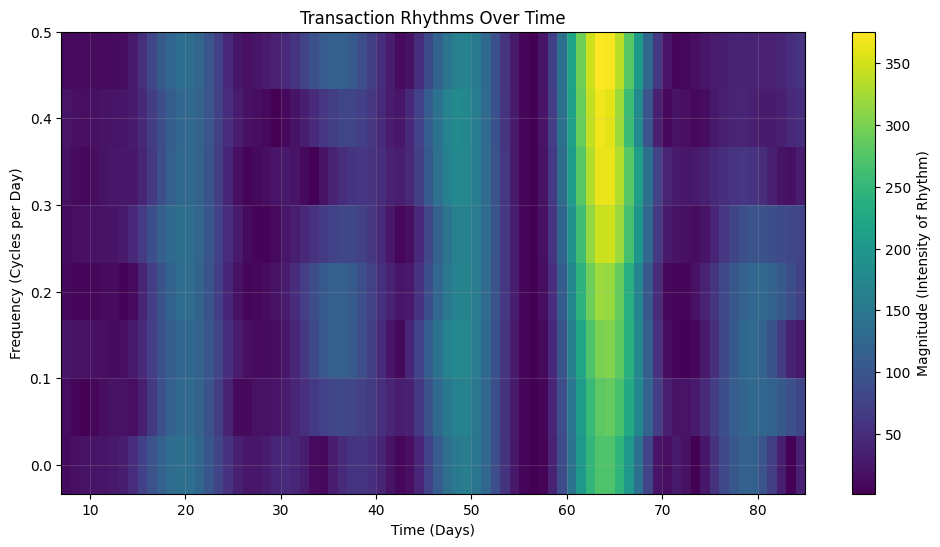

In [26]:
signal_nonfraud = get_customer_signal(daily_trans,'SYNID0100000485')   # SYNID0100000485 is non-fraud
f,t,tf_matrix = compute_tf_matrix(signal_nonfraud,15,1)  # set window days to 15 first
plot_tf_matrix(t,f,tf_matrix)

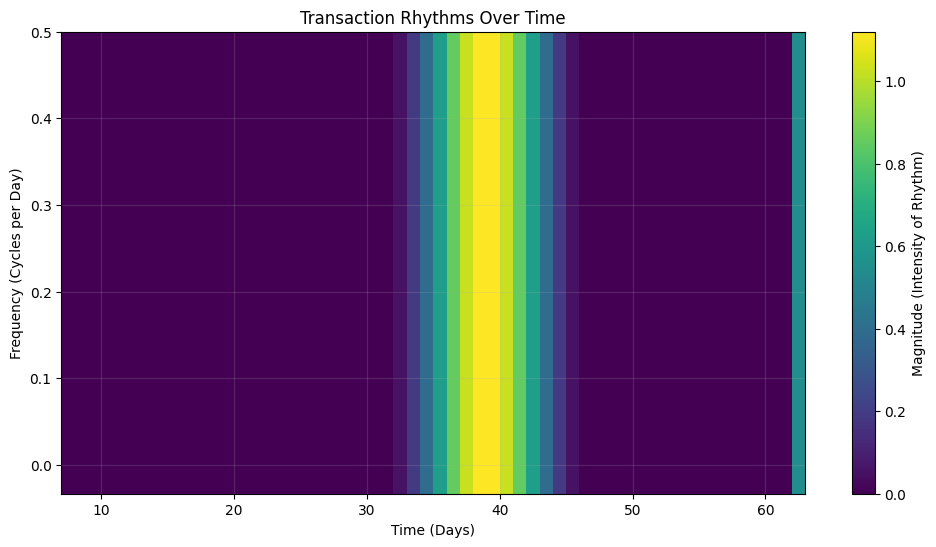

In [27]:
signal_fraud = get_customer_signal(daily_trans,'SYNID0101421130')   # SYNID0101421130 is fraud
f,t,tf_matrix = compute_tf_matrix(signal_fraud,15,1)  # set window days to 15 first
plot_tf_matrix(t,f,tf_matrix)

represent the tf matrix with features

In [28]:
# to cut time effectively, we compute the batch stft for all customers

def get_all_signals_matrix(df):
    """
    Returns: 
        signals_array: Numpy array (Days x Customers)
        customer_ids: List of customer IDs
    """
    print("Step 1: Creating Customer Signals Matrix...")
    
    # Pivot table
    matrix = df.pivot_table(
        index='date', 
        columns='customer_id', 
        values='net_flow_per_day', 
        fill_value=0
    )
    
    # Ensure daily frequency and fill missing days with 0
    matrix = matrix.asfreq('D', fill_value=0)
    
    return matrix.values, matrix.columns

In [29]:
def compute_batch_stft(signals_array, window_days, step_days=1):
    """
    Computes STFT for all customers simultaneously using vectorization.
    Input: 2D Array (Days x Customers)
    Output: 3D Tensor (Frequencies x TimeBins x Customers)
    """
    print("Step 2: Computing STFT for all customers...")
    
    nperseg = window_days
    noverlap = nperseg - step_days
    
    # axis=0 tells scipy to run down the time column for everyone
    f, t, Zxx = stft(
        signals_array, 
        nperseg=nperseg, 
        noverlap=noverlap, 
        axis=0, 
        boundary=None
    )
    
    # Return the magnitude
    return np.abs(Zxx)

In [30]:
from scipy.stats import skew, kurtosis

def extract_all_tf_features(tf_tensor, customer_ids):

    print(f"1. Received Tensor Shape: {tf_tensor.shape}")
    
    num_customers = len(customer_ids)
    shape = tf_tensor.shape
    
    # --- AUTO-CORRECTION STEP ---
    # We want the final shape to be: (Freq, Time, Customers)
    
    if shape[2] == num_customers:
        pass
        
    elif shape[0] == num_customers:
        tf_tensor = tf_tensor.transpose(1, 2, 0)
        
    elif shape[1] == num_customers:
        tf_tensor = tf_tensor.transpose(0, 2, 1)
        
    else:
        raise ValueError(f"Tensor shape {shape} does not match customer count {num_customers}!")

    print(f"2. Processing Corrected Tensor: {tf_tensor.shape}...")

    # --- STANDARD MATH ---
    
    # 1. Flatten Frequency and Time
    n_freqs, n_times, n_cust = tf_tensor.shape
    
    # ensure memory is contiguous for reshape
    tf_tensor = tf_tensor.copy()
    tf_flat = tf_tensor.reshape(-1, n_cust) 
    
    # 2. Energies
    time_energy = tf_tensor.sum(axis=0) # Sum over Freq -> (Time, Cust)
    freq_energy = tf_tensor.sum(axis=1) # Sum over Time -> (Freq, Cust)
    
    # 3. Basic Moments
    tf_mean = tf_flat.mean(axis=0)
    tf_var = tf_flat.var(axis=0)
    
    # 4. Skew & Kurtosis
    tf_skew = skew(tf_flat, axis=0)
    tf_kurt = kurtosis(tf_flat, axis=0, fisher=False)
    
    mask_low_var = tf_var < 1e-10
    tf_skew[mask_low_var] = 0
    tf_kurt[mask_low_var] = 0
    
    # 5. Discontinuities
    disc_time = np.abs(np.diff(tf_tensor, axis=1)).mean(axis=(0, 1))
    disc_freq = np.abs(np.diff(tf_tensor, axis=0)).mean(axis=(0, 1))
    
    # Mixed Derivative
    term1 = tf_tensor[:-1, :-1, :] 
    term2 = tf_tensor[1:, 1:, :]   
    term3 = tf_tensor[1:, :-1, :]  
    term4 = tf_tensor[:-1, 1:, :] 
    disc_tf = np.abs(term1 + term2 - term3 - term4).mean(axis=(0, 1))
    
    # 6. Entropy
    total_energy = tf_flat.sum(axis=0, keepdims=True) + 1e-12
    p = tf_flat / total_energy
    tf_entropy = -np.sum(p * np.log(p + 1e-12), axis=0)
    
    # 7. Sparsity
    sparsity_time = (time_energy <= 1e-6).mean(axis=0)
    sparsity_freq = (freq_energy <= 1e-6).mean(axis=0)
    sparsity_tf   = (tf_flat <= 1e-6).mean(axis=0)

    # 8. Result
    data = {
        'tf_mean': tf_mean,
        'tf_var': tf_var,
        'tf_skew': tf_skew,
        'tf_kurt': tf_kurt,
        'sparsity_time': sparsity_time,
        'sparsity_freq': sparsity_freq,
        'sparsity_tf': sparsity_tf,
        'disc_time': disc_time,
        'disc_freq': disc_freq,
        'disc_tf': disc_tf,
        'tf_entropy': tf_entropy
    }
    
    return pd.DataFrame(data, index=customer_ids)

In [31]:
# Window Days = 7
signals, cust_ids = get_all_signals_matrix(daily_trans)
tf_tensor7 = compute_batch_stft(signals, window_days=7, step_days=1)  # set window days to be 7
tf_features7 = extract_all_tf_features(tf_tensor7, cust_ids)
print('Window = 7, Done!')

Step 1: Creating Customer Signals Matrix...
Step 2: Computing STFT for all customers...
1. Received Tensor Shape: (4, 61410, 86)
2. Processing Corrected Tensor: (4, 86, 61410)...
Window = 7, Done!


In [32]:
account_profiles = account_profiles.merge(tf_features7,on='customer_id',how='left')
account_profiles.head(5)

,customer_id,churn_anomaly_count,churn_symmetry_count,total_transaction_volume,peak_transaction,max_churn_z_score,std_churn_ratio,total_outbound_cad,outbound_income_ratio,revenue_capacity_ratio,...,tf_var,tf_skew,tf_kurt,sparsity_time,sparsity_freq,sparsity_tf,disc_time,disc_freq,disc_tf,tf_entropy
0,SYNID0100000167,2,0,8165.17,3236.46,8.412867e+00,19237.164242,1698.68,0.139373,NaN,...,3.295154e+04,2.373579,9.028929,0.313953,0.0,0.313953,55.875475,9.937100,8.554998,4.885735
1,SYNID0100000431,3,5,-6509.40,1753.40,4.239561e+00,53509.923375,14435.16,1.675520,NaN,...,1.370686e+04,0.913318,3.104619,0.000000,0.0,0.000000,58.173491,40.107464,34.096839,5.522114
2,SYNID0100000485,3,0,3614.68,2264.88,6.415987e+00,22692.409144,3688.32,0.739765,NaN,...,1.749098e+04,2.675572,11.080155,0.139535,0.0,0.139535,43.518576,12.223223,10.203804,5.065727
3,SYNID0100000539,37,0,-10079.19,148.19,4.552850e+06,44198.489264,10244.17,1.042425,NaN,...,4.697723e+03,1.236485,3.932277,0.000000,0.0,0.000000,30.549741,23.993050,13.544290,5.524170
4,SYNID0100000932,1,0,116107.66,125397.63,8.836664e+00,93064.584724,29703.61,3.485485,NaN,...,3.641485e+07,4.409324,21.866194,0.000000,0.0,0.000000,971.391536,93.650032,68.401525,3.914181


### Transaction amount per type ratio

In [34]:
# calculate the ratio of each type amount/total transaction amount (inbound+outbound)
trans_volume = transactions.copy()
trans_volume['amount_cad'] = abs(trans_volume['amount_cad'])

total_volume = trans_volume.groupby('customer_id')['amount_cad'].sum()
type_sums = trans_volume.pivot_table(
    index='customer_id', 
    columns='type', 
    values='amount_cad', 
    aggfunc='sum', 
    fill_value=0
)

trans_type_proportions = type_sums.div(total_volume, axis=0)
trans_type_proportions = trans_type_proportions.add_prefix('prop_').reset_index()
trans_type_proportions


type,customer_id,prop_abm,prop_card,prop_cheque,prop_eft,prop_emt,prop_westernunion,prop_wire
0,SYNID0100000167,0.000000,0.000000,0.070162,0.929838,0.000000,0.000000,0.0
1,SYNID0100000431,0.197739,0.097038,0.000000,0.294767,0.374456,0.035999,0.0
2,SYNID0100000485,0.071578,0.106661,0.000000,0.821760,0.000000,0.000000,0.0
3,SYNID0100000539,0.000000,0.817847,0.000000,0.032832,0.149322,0.000000,0.0
4,SYNID0100000932,0.012255,0.794909,0.016035,0.176624,0.000176,0.000000,0.0
...,...,...,...,...,...,...,...,...
61405,SYNID0200999416,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0
61406,SYNID0200999425,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0
61407,SYNID0200999482,0.039151,0.000012,0.960838,0.000000,0.000000,0.000000,0.0
61408,SYNID0200999834,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0


In [35]:
account_profiles = account_profiles.merge(trans_type_proportions,on='customer_id',how='left')

In [ ]:
#account_profiles.to_csv('account_profiles.csv')

## Isolation forest

In [37]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

In [39]:
#account_profiles = pd.read_csv('account_profiles.csv')

In [63]:
individual_account = account_profiles[account_profiles['customer_id'].isin(kyc_individual['customer_id'])]
business_account = account_profiles[account_profiles['customer_id'].isin(kyc_smallbusiness['customer_id'])]

#### Individual accounts

In [48]:
individual_features = individual_account.drop(columns=['customer_id','revenue_capacity_ratio','age',
                                                       'total_outbound_cad','peak_transaction',
                                                       'tf_kurt','disc_tf','disc_freq',
                                                       'tf_mean','tf_var','tf_skew','sparsity_freq','sparsity_tf','disc_time','disc_freq','disc_tf',
                                                       'sparsity_time','tf_entropy',
                                                       # 'account_age',
                                                       'prop_card','prop_cheque','prop_wire',
                                                       # 'prop_abm','prop_emt','prop_eft','prop_wire','prop_westernunion',
                                                       #'max_churn_z_score'
                                                       ])

# Replace infinite values with NaN so they can be imputed
individual_features.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute missing values with the median (more robust to outliers than the mean)
imputer = SimpleImputer(strategy='median')
individual_features_imputed = imputer.fit_transform(individual_features)

# Run Isolation Forest
# contamination='auto' lets the model decide the threshold, or can set it to a float (e.g., 0.05 for 5% expected anomalies)
model = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
model.fit(individual_features_imputed)

# get anomaly score and anomaly flag
individual_account['anomaly_score'] = model.decision_function(individual_features_imputed)
individual_account['is_anomaly'] = model.fit_predict(individual_features_imputed)

# get the raw 'score_samples'
raw_scores = model.score_samples(individual_features_imputed)

# define the normalization constant c(n)
def c_factor(n):
    if n <= 1: return 0
    if n == 2: return 1
    return 2 * (np.log(n - 1) + 0.5772156649) - (2 * (n - 1) / n)

# calculate Average Path Length E(h(x))
# Formula: E(h(x)) = -log2(-score_samples) * c(n)
n_samples = individual_features_imputed.shape[0]
max_samples = min(256, n_samples) # Default max_samples in sklearn is 256
c_val = c_factor(max_samples)

individual_account['avg_path_length'] = -np.log2(-raw_scores) * c_val

individual_account

C:\Users\annxy\AppData\Local\Temp\ipykernel_28456\499141880.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  individual_account['anomaly_score'] = model.decision_function(individual_features_imputed)
C:\Users\annxy\AppData\Local\Temp\ipykernel_28456\499141880.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  individual_account['is_anomaly'] = model.fit_predict(individual_features_imputed)
C:\Users\annxy\AppData\Local\Temp\ipykernel_28456\499141880.py:43: SettingWithCopyWarning: 
A value is trying to 

,customer_id,churn_anomaly_count,churn_symmetry_count,total_transaction_volume,peak_transaction,max_churn_z_score,std_churn_ratio,total_outbound_cad,outbound_income_ratio,revenue_capacity_ratio,...,prop_abm,prop_card,prop_cheque,prop_eft,prop_emt,prop_westernunion,prop_wire,anomaly_score,is_anomaly,avg_path_length
0,SYNID0100000167,2,0,8165.17,3236.46,8.412867e+00,19237.164242,1698.68,0.139373,NaN,...,0.000000,0.000000,0.070162,0.929838,0.000000,0.000000,0.0,0.129677,1,14.682234
1,SYNID0100000431,3,5,-6509.40,1753.40,4.239561e+00,53509.923375,14435.16,1.675520,NaN,...,0.197739,0.097038,0.000000,0.294767,0.374456,0.035999,0.0,0.020384,1,10.859958
2,SYNID0100000485,3,0,3614.68,2264.88,6.415987e+00,22692.409144,3688.32,0.739765,NaN,...,0.071578,0.106661,0.000000,0.821760,0.000000,0.000000,0.0,0.137339,1,14.991249
3,SYNID0100000539,37,0,-10079.19,148.19,4.552850e+06,44198.489264,10244.17,1.042425,NaN,...,0.000000,0.817847,0.000000,0.032832,0.149322,0.000000,0.0,-0.144208,-1,6.499305
4,SYNID0100000932,1,0,116107.66,125397.63,8.836664e+00,93064.584724,29703.61,3.485485,NaN,...,0.012255,0.794909,0.016035,0.176624,0.000176,0.000000,0.0,0.087295,1,13.080688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53094,SYNID0109999056,1,1,13215.17,4405.04,9.170426e+00,14821.576392,1683.64,0.155439,NaN,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.079376,1,12.799768
53095,SYNID0109999204,2,1,-1873.56,339.51,5.161660e+00,17387.087315,2419.34,inf,NaN,...,0.052430,0.615688,0.000000,0.000000,0.331882,0.000000,0.0,0.129108,1,14.659523
53096,SYNID0109999322,0,6,-2589.71,1491.89,2.831703e+00,12456.822812,11484.33,1.444360,NaN,...,0.019628,0.260857,0.139914,0.411694,0.167907,0.000000,0.0,0.139548,1,15.081537
53097,SYNID0109999736,2,6,18647.03,4114.21,7.581671e+00,49737.193666,21113.75,2.218186,NaN,...,0.000000,0.009107,0.000000,0.463460,0.527432,0.000000,0.0,0.121610,1,14.363722


In [47]:
# Check the accuracy of isolation forest on our labelled data

nonfraud_customers = labels[labels['label'] == 0]['customer_id'].unique()
fraud_customers = labels[labels['label'] == 1]['customer_id'].unique()
print('individuals labelled as 1')
print(individual_account[individual_account['customer_id'].isin(fraud_customers)]['is_anomaly'].value_counts())
print('\n')
print ('individuals labeled as 0')
print(individual_account[individual_account['customer_id'].isin(nonfraud_customers)]['is_anomaly'].value_counts())

individuals labelled as 1
is_anomaly
 1    5
-1    1
Name: count, dtype: int64


individuals labeled as 0
is_anomaly
 1    894
-1     12
Name: count, dtype: int64


In [43]:
import shap

# Isolation Forest is a tree-based ensemble, so we use TreeExplainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for your imputed features
shap_values = explainer.shap_values(individual_features_imputed)

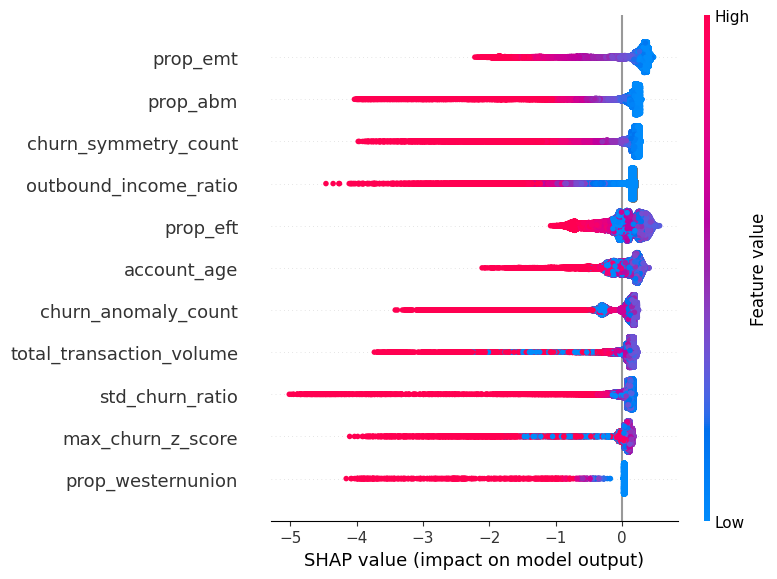

In [72]:
shap.summary_plot(shap_values, individual_features)

#### Business accounts

In [64]:
business_features = business_account.drop(columns=['customer_id','outbound_income_ratio','age',
                                                       #'total_outbound_cad','peak_transaction',
                                                       #'tf_kurt','disc_tf','disc_freq',
                                                       #'tf_mean','tf_var','tf_skew','sparsity_freq','sparsity_tf','disc_time',
                                                       'sparsity_time','tf_entropy',
                                                       'account_age',
                                                       #'prop_card','prop_cheque',
                                                       #'prop_abm','prop_eft',
                                                       'total_transaction_volume',
                                                       'prop_wire','prop_westernunion','prop_emt',
                                                       #'max_churn_z_score'
                                                       ])

# Replace infinite values with NaN so they can be imputed
business_features.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute missing values with the median (more robust to outliers than the mean)
imputer = SimpleImputer(strategy='median')
business_features_imputed = imputer.fit_transform(business_features)

# Run Isolation Forest
# contamination='auto' lets the model decide the threshold, or can set it to a float (e.g., 0.05 for 5% expected anomalies)
model = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
model.fit(business_features_imputed)

# get anomaly score and anomaly flag
business_account['anomaly_score'] = model.decision_function(business_features_imputed)
business_account['is_anomaly'] = model.fit_predict(business_features_imputed)

# get the raw 'score_samples'
raw_scores = model.score_samples(business_features_imputed)

# define the normalization constant c(n)
def c_factor(n):
    if n <= 1: return 0
    if n == 2: return 1
    return 2 * (np.log(n - 1) + 0.5772156649) - (2 * (n - 1) / n)

# calculate Average Path Length E(h(x))
# Formula: E(h(x)) = -log2(-score_samples) * c(n)
n_samples = business_features_imputed.shape[0]
max_samples = min(256, n_samples) # Default max_samples in sklearn is 256
c_val = c_factor(max_samples)

business_account['avg_path_length'] = -np.log2(-raw_scores) * c_val

business_account

C:\Users\annxy\AppData\Local\Temp\ipykernel_28456\2618207822.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_account['anomaly_score'] = model.decision_function(business_features_imputed)
C:\Users\annxy\AppData\Local\Temp\ipykernel_28456\2618207822.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_account['is_anomaly'] = model.fit_predict(business_features_imputed)
C:\Users\annxy\AppData\Local\Temp\ipykernel_28456\2618207822.py:45: SettingWithCopyWarning: 
A value is trying to be se

,customer_id,churn_anomaly_count,churn_symmetry_count,total_transaction_volume,peak_transaction,max_churn_z_score,std_churn_ratio,total_outbound_cad,outbound_income_ratio,revenue_capacity_ratio,...,prop_abm,prop_card,prop_cheque,prop_eft,prop_emt,prop_westernunion,prop_wire,anomaly_score,is_anomaly,avg_path_length
53099,SYNID0200000024,2,7,-1378357.03,29446.67,8.440724,2.027440e+05,1537957.74,NaN,33.917238,...,0.000000,0.000000,0.188644,0.811299,0.000056,0.0,0.00000,-0.051681,-1,8.790988
53100,SYNID0200000050,2,0,9719.68,5595.25,7.142729,4.978619e+04,3902.13,NaN,0.062603,...,0.000000,0.006646,0.348039,0.645314,0.000000,0.0,0.00000,0.140016,1,15.100764
53101,SYNID0200000104,1,0,46333.07,39275.83,8.120052,6.589917e+03,233.62,NaN,0.005512,...,0.000000,0.000000,0.839222,0.160778,0.000000,0.0,0.00000,0.130494,1,14.714861
53102,SYNID0200000167,1,0,-27303.78,3803.18,6.528567,1.946250e+05,43576.82,NaN,inf,...,0.000000,0.000000,0.003203,0.599617,0.000000,0.0,0.39718,0.120070,1,14.303703
53103,SYNID0200000345,1,0,-26087.17,5822.97,9.249653,5.194373e+05,36786.18,NaN,inf,...,0.000000,0.000000,0.622593,0.377407,0.000000,0.0,0.00000,0.138578,1,15.041834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61405,SYNID0200999416,2,0,-475.34,-0.00,6.701283,1.089095e+04,475.34,NaN,0.017854,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.102005,1,13.617110
61406,SYNID0200999425,3,0,8785.63,7294.78,6.121905,7.324967e+04,3847.46,NaN,inf,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.00000,0.131658,1,14.761492
61407,SYNID0200999482,2,0,-373444.93,40858.85,6.821300,1.400453e+07,492688.16,NaN,inf,...,0.039151,0.000012,0.960838,0.000000,0.000000,0.0,0.00000,0.000591,1,10.262256
61408,SYNID0200999834,1,0,-18065.22,-32.90,9.486817,1.272751e+06,18065.22,NaN,2.426069,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.00000,0.109323,1,13.891420


In [65]:
print('businesses labelled as 1')
print(business_account[business_account['customer_id'].isin(fraud_customers)]['is_anomaly'].value_counts())
print('\n')
print('businesses labelled as 0')
print(business_account[business_account['customer_id'].isin(nonfraud_customers)]['is_anomaly'].value_counts())

businesses labelled as 1
is_anomaly
1    4
Name: count, dtype: int64


businesses labelled as 0
is_anomaly
1    84
Name: count, dtype: int64


In [66]:
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for your imputed features
shap_values = explainer.shap_values(business_features_imputed)

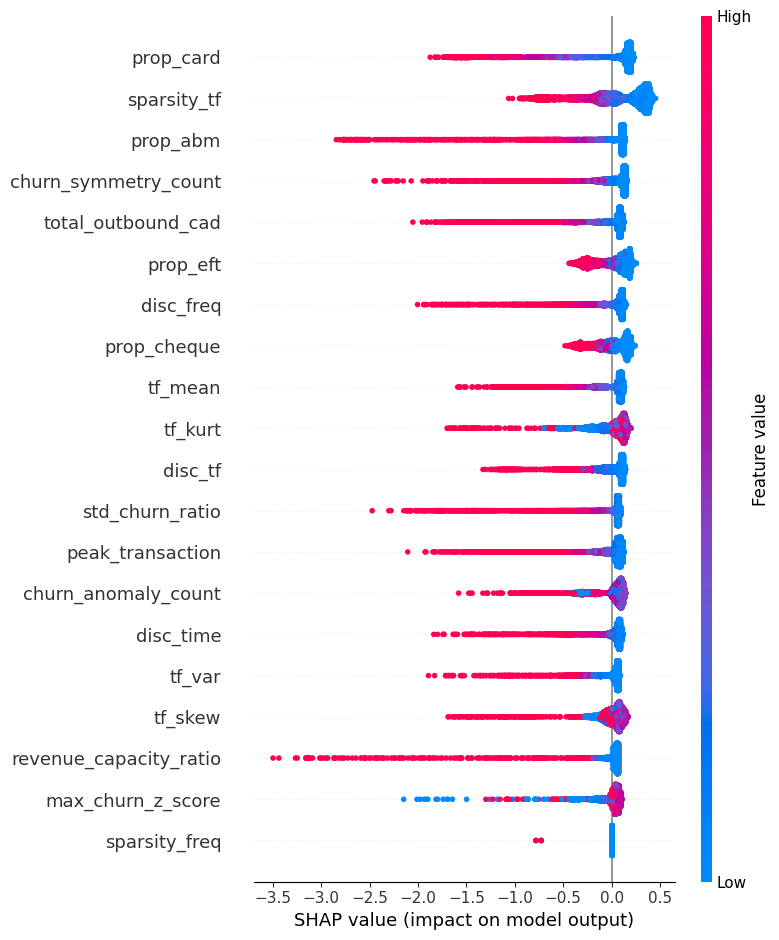

In [67]:
shap.summary_plot(shap_values, business_features)

## AutoEncoder

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [69]:
# prepare non-fraud individual customer profile
nonfraud_ind_profile = individual_account[individual_account['customer_id'].isin(nonfraud_customers)].drop(columns='revenue_capacity_ratio')
nonfraud_bus_profile = business_account[business_account['customer_id'].isin(nonfraud_customers)].drop(columns='outbound_income_ratio')
other_ind = individual_account[~individual_account['customer_id'].isin(nonfraud_customers)].drop(columns='revenue_capacity_ratio')
other_bus = business_account[~business_account['customer_id'].isin(nonfraud_customers)].drop(columns='outbound_income_ratio')

#### Individual accounts

In [70]:
nonfraud_ind_profile.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy='median')
scaler = RobustScaler()

X_clean = imputer.fit_transform(nonfraud_ind_profile.drop(columns=['customer_id']))
X_train = scaler.fit_transform(X_clean)

other_ind.replace([np.inf, -np.inf], np.nan, inplace=True)
X_rest_clean = imputer.fit_transform(other_ind.drop(columns=['customer_id']))
X_rest = scaler.transform(X_rest_clean)

In [71]:
# build auto encoder
input_dim = X_train.shape[1]
# Bottleneck: force the model to learn the most important patterns
encoding_dim = int(input_dim / 1.5) 

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation='relu')(input_layer)
encoder = Dense(int(encoding_dim/2), activation='relu')(encoder)

decoder = Dense(int(encoding_dim/2), activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

In [72]:
# train on non-fraud individuals
autoencoder.fit(X_train, X_train, epochs=100, batch_size=64, shuffle=True, verbose=1)

# predict on others
reconstructions = autoencoder.predict(X_rest)

# Calculate Reconstruction Error (MSE)
mse = np.mean(np.power(X_rest - reconstructions, 2), axis=1)

# Use the 99th percentile of the TRAIN error as the cutoff
train_reconstructions = autoencoder.predict(X_train)
train_mse = np.mean(np.power(X_train - train_reconstructions, 2), axis=1)
threshold = np.percentile(train_mse, 99) 

other_ind['reconstruction_error'] = mse
other_ind['is_suspicious'] = other_ind['reconstruction_error'] > threshold

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4873242112.0000    
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4336002048.0000 
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4061354752.0000 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3906545920.0000  
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3741102080.0000
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3575333888.0000
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3382132224.0000  
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3125286656.0000
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2874699520.0000
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2548118016.0000 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2114198912.0000
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1620707072.0000
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1180859520.0000 
Epoch 14/

In [ ]:
# check if we can identify the fraud customers with this model -- seems we cannot. should improve the features


other_ind[other_ind.customer_id.isin(fraud_customers)]

,customer_id,churn_anomaly_count,churn_symmetry_count,total_transaction_volume,peak_transaction,max_churn_z_score,std_churn_ratio,total_outbound_cad,outbound_income_ratio,account_age,...,tf_entropy,prop_abm,prop_card,prop_cheque,prop_eft,prop_emt,prop_westernunion,prop_wire,reconstruction_error,is_suspicious
5081,SYNID0100957188,4,3,15166.25,500.00,3.691372,0.406196,2390.60,1198.583791,5720,...,5.629661,0.143130,0.001781,0.0,0.000000,0.855089,0.0,0.000000,6.412570,False
7487,SYNID0101421130,2,0,-159.45,-8.49,8.133223,4329.190686,159.45,0.005707,1737,...,3.850630,0.000000,1.000000,0.0,0.000000,0.000000,0.0,0.000000,1.254983,False
29826,SYNID0105593361,2,5,-20648.78,6100.00,3.593652,163875.104306,44572.85,16252.837413,2183,...,5.521198,0.276204,0.649378,0.0,0.060863,0.013555,0.0,0.000000,69.960898,False
39105,SYNID0107334515,0,1,27855.78,5479.96,2.772471,29379.387617,13290.74,NaN,2004,...,5.330576,0.011193,0.123228,0.0,0.773050,0.072140,0.0,0.020390,1.620723,False
39794,SYNID0107464935,3,0,22714.04,13383.46,6.881914,15734.937390,1174.24,523.318193,523,...,4.532091,0.000000,0.000318,0.0,0.465679,0.000000,0.0,0.534003,5.765608,False
41771,SYNID0107832828,5,1,-9857.24,2136.07,4.549516,88298.295553,17236.56,NaN,376,...,5.285594,0.000000,0.001776,0.0,0.000000,0.998224,0.0,0.000000,0.897924,False


In [74]:
other_ind.is_suspicious.value_counts()

is_suspicious
False    50542
True      1651
Name: count, dtype: int64